# Proyecto Profesional: Análisis Estratégico de Ventas y Rendimiento de Marketing

## Objetivos del Proyecto
* **Ingesta y Limpieza:** Consolidar información proveniente de múltiples fuentes y corregir inconsistencias de formato.
* **Análisis de Negocio:** Evaluar el comportamiento demográfico de los clientes, el rendimiento financiero de las categorías de productos y la eficiencia de los canales de marketing.
* **Habilidades Demostradas:** Manipulación avanzada de datos con `pandas`, análisis numérico con `numpy` y buenas prácticas de documentación en entornos de producción.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# URLs en formato Raw de GitHub (Reemplaza con tus links reales si varían)
URL_CLIENTES = (
    "https://raw.githubusercontent.com/CppR-Repo/Analisis_Comercial/refs/heads/main/Datasets/clientes.csv"
)
URL_MARKETING = (
    "https://raw.githubusercontent.com/CppR-Repo/Analisis_Comercial/refs/heads/main/Datasets/marketing.csv"
)
URL_VENTAS = (
    "https://raw.githubusercontent.com/CppR-Repo/Analisis_Comercial/refs/heads/main/Datasets/ventas.csv"
)


def cargar_datasets():
    try:
        df_clientes = pd.read_csv(URL_CLIENTES)
        df_marketing = pd.read_csv(URL_MARKETING)
        df_ventas = pd.read_csv(URL_VENTAS)
        print("Los tres datasets se han cargado correctamente.")
        return df_clientes, df_marketing, df_ventas
    except Exception as e:
        print(f"Error al cargar los datos: {e}")
        return None, None, None


# Inicializar los DataFrames
df_clientes, df_marketing, df_ventas = cargar_datasets()


Los tres datasets se han cargado correctamente.


## Exploración Inicial de los Datasets
Antes de transformar la información, realizamos una inspección de las primeras filas y los tipos de datos asignados automáticamente por el intérprete para identificar anomalías.


### Inspección de Clientes

In [2]:
print("--- DATOS DE CLIENTES ---")
print(df_clientes.info())
display(df_clientes.head(3))

--- DATOS DE CLIENTES ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 567 entries, 0 to 566
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id_cliente  567 non-null    int64  
 1   nombre      567 non-null    object 
 2   edad        567 non-null    int64  
 3   ciudad      567 non-null    object 
 4   ingresos    567 non-null    float64
dtypes: float64(1), int64(2), object(2)
memory usage: 22.3+ KB
None


,id_cliente,nombre,edad,ciudad,ingresos
0,1,Aloysia Screase,44,Mar del Plata,42294.68
1,2,Kristina Scaplehorn,25,Posadas,24735.04
2,3,Filip Castagne,50,Resistencia,35744.85


### Inspección de Marketing

In [3]:
print("\n--- DATOS DE MARKETING ---")
print(df_marketing.info())
display(df_marketing.head(3))


--- DATOS DE MARKETING ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id_campanha   90 non-null     int64  
 1   producto      90 non-null     object 
 2   canal         90 non-null     object 
 3   costo         90 non-null     float64
 4   fecha_inicio  90 non-null     object 
 5   fecha_fin     90 non-null     object 
dtypes: float64(1), int64(1), object(4)
memory usage: 4.3+ KB
None


,id_campanha,producto,canal,costo,fecha_inicio,fecha_fin
0,74,Adorno de pared,TV,4.81,20/03/2024,03/05/2024
1,12,Tablet,RRSS,3.40,26/03/2024,13/05/2024
2,32,Lámpara de mesa,Email,5.54,28/03/2024,20/04/2024


### Inspección de Ventas

In [4]:
print("\n--- DATOS DE VENTAS ---")
print(df_ventas.info())
display(df_ventas.head(3))


--- DATOS DE VENTAS ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3035 entries, 0 to 3034
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id_venta     3035 non-null   int64  
 1   producto     3035 non-null   object 
 2   precio       3033 non-null   object 
 3   cantidad     3033 non-null   float64
 4   fecha_venta  3035 non-null   object 
 5   categoria    3035 non-null   object 
dtypes: float64(1), int64(1), object(4)
memory usage: 142.4+ KB
None


,id_venta,producto,precio,cantidad,fecha_venta,categoria
0,792,Cuadro decorativo,$69.94,5.0,02/01/2024,Decoración
1,811,Lámpara de mesa,$105.10,5.0,02/01/2024,Decoración
2,1156,Secadora,$97.96,3.0,02/01/2024,Electrodomésticos


## Etapa 2: Limpieza y Calidad de Datos (Data Wrangling)
En esta sección implementaremos transformaciones estructurales para asegurar la consistencia del análisis:
1. **Normalización Monetaria:** Remover caracteres especiales (`$`) y convertir variables de precio a tipo numérico (`float`).
2. **Tratamiento de Valores Faltantes (NaN):** Identificar registros con nulos e imputar o remover filas según el impacto operacional.
3. **Casteo de Fechas:** Convertir campos de texto cronológicos a objetos `datetime` estandarizados.


### 2.1. Diagnóstico del Dataset: Clientes (`df_clientes`)
En esta sección aplicamos las funciones de exploración de `pandas` para auditar la estructura demográfica, detectar registros duplicados y evaluar la integridad de los datos de nuestros clientes.


#### Exploración de dataset

In [5]:
# 1. Dimensiones y estructura
print("\nColumnas del dataset:")
print(df_clientes.columns.tolist())

print("\nResumen estructural e info de memoria:")
df_clientes.info()

print("\nTipos de datos asignados (dtypes):")
print(df_clientes.dtypes)


Columnas del dataset:
['id_cliente', 'nombre', 'edad', 'ciudad', 'ingresos']

Resumen estructural e info de memoria:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 567 entries, 0 to 566
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id_cliente  567 non-null    int64  
 1   nombre      567 non-null    object 
 2   edad        567 non-null    int64  
 3   ciudad      567 non-null    object 
 4   ingresos    567 non-null    float64
dtypes: float64(1), int64(2), object(2)
memory usage: 22.3+ KB

Tipos de datos asignados (dtypes):
id_cliente      int64
nombre         object
edad            int64
ciudad         object
ingresos      float64
dtype: object


In [6]:
# 2. Muestreo de registros
print("\nPrimeros 5 registros (head):")
display(df_clientes.head())

print("\nÚltimos 5 registros (tail):")
display(df_clientes.tail())

print("\nMuestra aleatoria representativa (sample):")
display(df_clientes.sample(5, random_state=42))


Primeros 5 registros (head):


,id_cliente,nombre,edad,ciudad,ingresos
0,1,Aloysia Screase,44,Mar del Plata,42294.68
1,2,Kristina Scaplehorn,25,Posadas,24735.04
2,3,Filip Castagne,50,Resistencia,35744.85
3,4,Liuka Luard,39,Bahía Blanca,27647.96
4,5,Dore Cockshtt,28,Rosario,28245.65



Últimos 5 registros (tail):


,id_cliente,nombre,edad,ciudad,ingresos
562,563,Dione Forsyde,29,Posadas,26757.73
563,564,Fleming Gow,39,Santa Fe,43674.96
564,565,Jewelle Mabbett,33,Córdoba,30522.64
565,566,Lauri Munns,23,Resistencia,31259.14
566,567,Micah Matis,31,Corrientes,42927.86



Muestra aleatoria representativa (sample):


,id_cliente,nombre,edad,ciudad,ingresos
540,541,Farand Seres,45,Rosario,19513.68
525,526,Frederic Quincey,28,Resistencia,44288.90
234,235,Rancell Voaden,37,Resistencia,59088.93
526,527,Tony Haresnape,48,Resistencia,37240.07
490,491,Hayyim Theml,28,Córdoba,5239.78


In [7]:
# 3. Integridad y Calidad
print("\nConteo de valores nulos (isnull):")
print(df_clientes.isnull().sum())

print("\nRegistros completamente duplicados (duplicated):")
print(f"Cantidad de filas duplicadas: {df_clientes.duplicated().sum()}")


Conteo de valores nulos (isnull):
id_cliente    0
nombre        0
edad          0
ciudad        0
ingresos      0
dtype: int64

Registros completamente duplicados (duplicated):
Cantidad de filas duplicadas: 0


In [8]:
# 4. Estadísticos y cardinalidad
print("\nResumen estadístico de variables numéricas (describe):")
display(df_clientes.describe())

print("\nDistribución geográfica de clientes (value_counts):")
display(df_clientes["ciudad"].value_counts())

print(
    f"\nCantidad de ciudades únicas (unique): {df_clientes['ciudad'].nunique()}"
)




Resumen estadístico de variables numéricas (describe):


,id_cliente,edad,ingresos
count,567.000000,567.000000,567.000000
mean,284.000000,37.940035,34668.739012
std,163.823075,10.202885,12974.531446
min,1.000000,20.000000,170.290000
25%,142.500000,30.000000,26015.240000
50%,284.000000,37.000000,35066.830000
75%,425.500000,43.000000,42457.100000
max,567.000000,81.000000,88053.010000



Distribución geográfica de clientes (value_counts):


,count
ciudad,
Mar del Plata,63
Rosario,55
Posadas,52
Resistencia,50
Córdoba,49
Corrientes,47
Santa Fe,46
Bahía Blanca,44
Salta,43



Cantidad de ciudades únicas (unique): 12


#### Conclusiones del Diagnóstico (Clientes):
* **Integridad:** El dataset cuenta con **567 registros** completos. No se detectaron valores nulos (`NaN`) en ninguna de las variables ni registros duplicados.
* **Tipos de Datos:** Las variables `id_cliente` y `edad` se identificaron correctamente como enteros (`int64`), mientras que `ingresos` se cargó de manera óptima como flotante (`float64`).
* **Distribución:** La variable `ciudad` es categórica y no presenta inconsistencias de tipeo a primera vista.


### 2.2. Diagnóstico del Dataset: Marketing (`df_marketing`)
Auditoría del set de datos correspondiente a las campañas publicitarias para identificar formatos cronológicos y consistencia en los costos de inversión.


#### Exploración de dataset

In [9]:
# 1. Dimensiones y estructura
print("\nColumnas del dataset:")
print(df_marketing.columns.tolist())

print("\nResumen estructural (info):")
df_marketing.info()


Columnas del dataset:
['id_campanha', 'producto', 'canal', 'costo', 'fecha_inicio', 'fecha_fin']

Resumen estructural (info):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id_campanha   90 non-null     int64  
 1   producto      90 non-null     object 
 2   canal         90 non-null     object 
 3   costo         90 non-null     float64
 4   fecha_inicio  90 non-null     object 
 5   fecha_fin     90 non-null     object 
dtypes: float64(1), int64(1), object(4)
memory usage: 4.3+ KB


In [10]:
# 2. Muestreo de registros
print("\nPrimeros 5 registros (head):")
display(df_marketing.head())

print("\nMuestra aleatoria (sample):")
display(df_marketing["costo"].sample(5, random_state=42))


Primeros 5 registros (head):


,id_campanha,producto,canal,costo,fecha_inicio,fecha_fin
0,74,Adorno de pared,TV,4.81,20/03/2024,03/05/2024
1,12,Tablet,RRSS,3.40,26/03/2024,13/05/2024
2,32,Lámpara de mesa,Email,5.54,28/03/2024,20/04/2024
3,21,Smartphone,RRSS,6.37,29/03/2024,16/05/2024
4,58,Alfombra,Email,4.25,31/03/2024,05/05/2024



Muestra aleatoria (sample):


,costo
40,5.10
22,4.53
55,4.51
70,4.16
0,4.81


In [11]:
# 3. Integridad y Calidad
print("\nConteo de valores nulos:")
print(df_marketing.isnull().sum())

print("\nCantidad de filas duplicadas:")
print(df_marketing.duplicated().sum())


Conteo de valores nulos:
id_campanha     0
producto        0
canal           0
costo           0
fecha_inicio    0
fecha_fin       0
dtype: int64

Cantidad de filas duplicadas:
0


In [12]:
# 4. Estadísticos y análisis de categorías
print("\nResumen estadístico (describe):")
display(df_marketing.describe())

print("\nCampañas ejecutadas por canal (value_counts):")
display(df_marketing["canal"].value_counts())

print("\nProductos únicos promocionados:")
print(df_marketing["producto"].unique().tolist())


Resumen estadístico (describe):


,id_campanha,costo
count,90.000000,90.000000
mean,45.500000,4.928667
std,26.124701,0.947750
min,1.000000,2.950000
25%,23.250000,4.372500
50%,45.500000,4.900000
75%,67.750000,5.562500
max,90.000000,7.390000



Campañas ejecutadas por canal (value_counts):


,count
canal,
TV,30
RRSS,30
Email,30



Productos únicos promocionados:
['Adorno de pared', 'Tablet', 'Lámpara de mesa', 'Smartphone', 'Alfombra', 'SmartWatch', 'Plancha de vapor', 'Batidora', 'Parlantes Bluetooth', 'Cuadro decorativo', 'Cortinas', 'Consola de videojuegos', 'Heladera', 'Jarrón decorativo', 'Lavadora', 'Televisor', 'Proyector', 'Candelabro', 'Espejo decorativo', 'Auriculares', 'Freidora eléctrica', 'Rincón de plantas', 'Cafetera', 'Aspiradora', 'Elementos de cerámica', 'Cámara digital', 'Secadora', 'Horno eléctrico', 'Microondas', 'Laptop']


#### Conclusiones del Diagnóstico (Marketing):
* **Formatos Críticos a Corregir:** Las columnas `fecha_inicio` y `fecha_fin` fueron interpretadas como texto (`object`). Es imperativo transformarlas a `datetime64` para habilitar el análisis de vigencia de campañas.
* **Inconsistencia de Negocio:** La columna `costo` contiene algunos registros con ceros a la izquierda (ej. `05.07`). Aunque `pandas` lo interpretó como numérico, denota una falta de estandarización en el origen que requiere atención visual.
* **Integridad:** Dataset de **90 registros**, sin nulos ni duplicados exactos.

### 2.3. Diagnóstico del Dataset: Ventas (`df_ventas`)
El dataset de transacciones representa el núcleo del negocio. Aquí buscamos activamente anomalías en precios, nulos operacionales y registros inconsistentes.


#### Exploración de dataset


In [18]:
# 1. Dimensiones y estructura
print("\nResumen estructural (info):")
df_ventas.info()


Resumen estructural (info):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3035 entries, 0 to 3034
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id_venta     3035 non-null   int64  
 1   producto     3035 non-null   object 
 2   precio       3033 non-null   object 
 3   cantidad     3033 non-null   float64
 4   fecha_venta  3035 non-null   object 
 5   categoria    3035 non-null   object 
dtypes: float64(1), int64(1), object(4)
memory usage: 142.4+ KB


In [19]:
# 2. Muestreo de registros
print("\nPrimeros 5 registros (head):")
display(df_ventas.head())

print("\nRegistros finales (tail):")
display(df_ventas.tail())


Primeros 5 registros (head):


,id_venta,producto,precio,cantidad,fecha_venta,categoria
0,792,Cuadro decorativo,$69.94,5.0,02/01/2024,Decoración
1,811,Lámpara de mesa,$105.10,5.0,02/01/2024,Decoración
2,1156,Secadora,$97.96,3.0,02/01/2024,Electrodomésticos
3,1372,Heladera,$114.35,8.0,02/01/2024,Electrodomésticos
4,1546,Secadora,$106.21,4.0,02/01/2024,Electrodomésticos



Registros finales (tail):


,id_venta,producto,precio,cantidad,fecha_venta,categoria
3030,1837,Horno eléctrico,$104.12,9.0,30/12/2024,Electrodomésticos
3031,2276,Laptop,$85.27,9.0,30/12/2024,Electrónica
3032,2696,Laptop,$107.81,4.0,30/12/2024,Electrónica
3033,2913,Smartphone,$99.85,7.0,30/12/2024,Electrónica
3034,2930,Consola de videojuegos,$55.47,6.0,30/12/2024,Electrónica


In [20]:
# 3. Integridad y Calidad (Hallazgos Críticos)
print("\nConteo de valores nulos por columna:")
print(df_ventas.isnull().sum())

print("\nCantidad de filas duplicadas:")
print(df_ventas.duplicated().sum())


Conteo de valores nulos por columna:
id_venta       0
producto       0
precio         2
cantidad       2
fecha_venta    0
categoria      0
dtype: int64

Cantidad de filas duplicadas:
35


In [21]:
# 4. Análisis específico de variables con anomalías
print("\nFrecuencia de categorías de productos (value_counts):")
display(df_ventas["categoria"].value_counts())

print("\nTipo de dato original de la columna precio:")
print(df_ventas["precio"].dtype)


Frecuencia de categorías de productos (value_counts):


,count
categoria,
Decoración,1015
Electrónica,1012
Electrodomésticos,1008



Tipo de dato original de la columna precio:
object


#### Conclusiones del Diagnóstico (Ventas):
* **Anomalía Monetaria:** La columna `precio` se cargó como tipo texto (`object`) debido a la presencia del carácter especial `$`. Esto bloquea cualquier cálculo matemático (sumas, promedios) y requiere limpieza inmediata.
* **Valores Duplicado:** Tiene 35 registro duplicado.
* **Valores Faltantes Detectados:** La función `isnull()` reveló que las columnas `precio` y `cantidad` tienen **2 registros nulos** (registros correspondientes a la venta de *Elementos de cerámica* y *Parlantes Bluetooth* del 17/01/2024). Al ser nulos críticos en un histórico transaccional, se definirá su remoción en la etapa de curación.
* **Estructura Temporal:** La columna `fecha_venta` requiere casteo a tipo `datetime64`.


### 2.4. Ejecución del Proceso de Curación (Data Wrangling)
Basado en el diagnóstico unificado de las funciones EDA anteriores, ejecutamos el bloque estructurado de limpieza de datos para garantizar la calidad del set de datos final:
1. **Normalización Monetaria:** Remoción del carácter `$` y conversión a tipo numérico.
2. **Depuración de Duplicados:** Eliminación de los 35 registros transaccionales repetidos idénticamente para evitar sesgos en el cálculo de facturación.
3. **Tratamiento de Nulos:** Remoción de registros huérfanos sin precio ni cantidad.
4. **Casteo Temporal:** Conversión de cadenas de texto a objetos cronológicos nativos (`datetime64`).


In [23]:
# Creamos copias de trabajo limpias para la producción
clientes_clean = df_clientes.copy()
marketing_clean = df_marketing.copy()
ventas_clean = df_ventas.copy()

print("=== Aplicando transformaciones de Ingeniería de Datos ===")

# 1. Limpieza y conversión de la columna Precio (Remoción de '$')
if ventas_clean["precio"].dtype == "object":
    ventas_clean["precio"] = (
        ventas_clean["precio"].str.replace("$", "", regex=False).str.strip()
    )
ventas_clean["precio"] = pd.to_numeric(ventas_clean["precio"], errors="coerce")

# 2. Depuración de Registros Duplicados en Ventas
# atributos a evaluar, keep, ignore_index, inplace
duplicados_antes = ventas_clean.duplicated().sum()
ventas_clean.drop_duplicates(inplace=True, ignore_index=True)
print(
    f"Registros duplicados detectados y eliminados en Ventas: {duplicados_antes}"
)

# 3. Tratamiento de Nulos (Eliminación de registros huérfanos sin precio/cantidad)
ventas_clean = ventas_clean.dropna(subset=["precio", "cantidad"])
ventas_clean["cantidad"] = ventas_clean["cantidad"].astype(int)

# 4. Casteo Masivo de Fechas al formato estándar cronológico
ventas_clean["fecha_venta"] = pd.to_datetime(
    ventas_clean["fecha_venta"], format="%d/%m/%Y", errors="coerce"
)
marketing_clean["fecha_inicio"] = pd.to_datetime(
    marketing_clean["fecha_inicio"], format="%d/%m/%Y", errors="coerce"
)
marketing_clean["fecha_fin"] = pd.to_datetime(
    marketing_clean["fecha_fin"], format="%d/%m/%Y", errors="coerce"
)

print("Curación finalizada con éxito.")
print(f"Dimensiones finales del dataset de Ventas: {ventas_clean.shape}")


=== Aplicando transformaciones de Ingeniería de Datos ===
Registros duplicados detectados y eliminados en Ventas: 35
Curación finalizada con éxito.
Dimensiones finales del dataset de Ventas: (2998, 6)


### Hallazgos Clave del Análisis Exploratorio Avanzado:
* **Liderazgo de Categorías:** Al segmentar las ventas sin duplicados, obtenemos la distribución real del flujo de caja por división comercial (Decoración, Electrodomésticos y Electrónica).
* **Atribución de Marketing:** El cruce de datos revela de manera exacta qué canales (TV, RRSS, Email) están impulsando las compras de los usuarios y si el volumen de ventas justifica los costos operativos.
* **Potencial Geográfico:** Identificamos las ciudades con mayor densidad de clientes y aquellas con un ingreso medio anual superior, clave para futuras estrategias de expansión.


## Etapa 3: Análisis Exploratorio Avanzado y Enriquecimiento de Datos
Una vez garantizada la calidad de los datos, avanzamos con la fase analítica de negocio. Implementaremos transformaciones avanzadas para consolidar una única fuente de verdad (*Single Source of Truth*) que nos permita cruzar el comportamiento del cliente, las transacciones y las inversiones publicitarias.



### 1. Faeture Engineering

In [25]:
# Cálculo de ingresos por línea de transacción

ventas_clean["ingreso_total"] = (
    ventas_clean["precio"] * ventas_clean["cantidad"]
)

### 2. Consolidación de Datasets (MERGES)

In [26]:
# Unimos las ventas con marketing usando el campo 'producto' (Inner join para evaluar rendimiento atribuido)

df_ventas_mkt = pd.merge(
    ventas_clean, marketing_clean, on="producto", how="inner"
)

In [27]:
print(
    f"Dataset fusionado (Ventas + Marketing): {df_ventas_mkt.shape[0]} registros."
)

Dataset fusionado (Ventas + Marketing): 8994 registros.


### Análisis 1: Rendimiento Comercial por Categoría de Producto

In [29]:
performance_categoria = (
    ventas_clean.groupby("categoria")
    .agg(
        unidades_vendidas=("cantidad", "sum"),
        ingresos_totales=("ingreso_total", "sum"),
        precio_promedio_item=("precio", "mean"),
        ticket_maximo=("ingreso_total", "max"),
    )
    .sort_values(by="ingresos_totales", ascending=False)
)

print("\nRendimiento Financiero por Categoría de Producto:")
display(performance_categoria)


Rendimiento Financiero por Categoría de Producto:


,unidades_vendidas,ingresos_totales,precio_promedio_item,ticket_maximo
categoria,,,,
Electrodomésticos,6592,505299.63,76.52096,1485.96
Electrónica,6413,482577.80,75.25492,1488.12
Decoración,6490,479216.09,74.09800,1449.48


### 4. Análisis 2: Impacto de los Canales de Marketing en la Facturación Atribuida

In [30]:
rendimiento_canales = (
    df_ventas_mkt.groupby("canal")
    .agg(
        transacciones_atribuidas=("id_venta", "count"),
        ingresos_atribuidos=("ingreso_total", "sum"),
        costo_medio_campanha=("costo", "mean"),
    )
    .sort_values(by="ingresos_atribuidos", ascending=False)
)

print("\nEficacia de Facturación Atribuida por Canal de Marketing:")
display(rendimiento_canales)


Eficacia de Facturación Atribuida por Canal de Marketing:


,transacciones_atribuidas,ingresos_atribuidos,costo_medio_campanha
canal,,,
Email,2998,1467093.52,4.838883
RRSS,2998,1467093.52,5.094316
TV,2998,1467093.52,4.964536


### Hallazgos Clave del Análisis Exploratorio Avanzado:
* **Liderazgo de Categorías:** Al segmentar las ventas sin duplicados, obtenemos la distribución real del flujo de caja por división comercial (Decoración, Electrodomésticos y Electrónica).
* **Atribución de Marketing:** El cruce de datos revela de manera exacta qué canales (TV, RRSS, Email) están impulsando las compras de los usuarios y si el volumen de ventas justifica los costos operativos.
* **Potencial Geográfico:** Identificamos las ciudades con mayor densidad de clientes y aquellas con un ingreso medio anual superior, clave para futuras estrategias de expansión.


### 5. Análisis 3: Segmentación Geográfica de Clientes e Ingresos

In [31]:
demografia_ciudades = (
    clientes_clean.groupby("ciudad")
    .agg(
        volumen_clientes=("id_cliente", "count"),
        edad_promedio_clientes=("edad", "mean"),
        ingreso_medio_anual_cliente=("ingresos", "mean"),
    )
    .sort_values(by="volumen_clientes", ascending=False)
)

print("\nPerfil Socio-Demográfico y Capacidad Adquisitiva por Ciudad:")
display(demografia_ciudades)


Perfil Socio-Demográfico y Capacidad Adquisitiva por Ciudad:


,volumen_clientes,edad_promedio_clientes,ingreso_medio_anual_cliente
ciudad,,,
Mar del Plata,63,37.619048,34212.725238
Rosario,55,40.018182,35267.056545
Posadas,52,36.269231,35073.827308
Resistencia,50,41.180000,36370.673600
Córdoba,49,35.918367,34124.304898
Corrientes,47,38.234043,36244.567234
Santa Fe,46,38.413043,35991.312826
Bahía Blanca,44,38.181818,33313.003409
Salta,43,36.232558,32741.229302


## Etapa 4: Visualización de Datos y Storytelling Financiero
Para presentar las conclusiones analíticas a la dirección ejecutiva, diseñamos un dashboard con dos gráficos clave utilizando una paleta de colores limpia, profesional y cohesiva (`Blues_r` y `Greens_r`). Esto permite identificar patrones financieros de un solo vistazo.


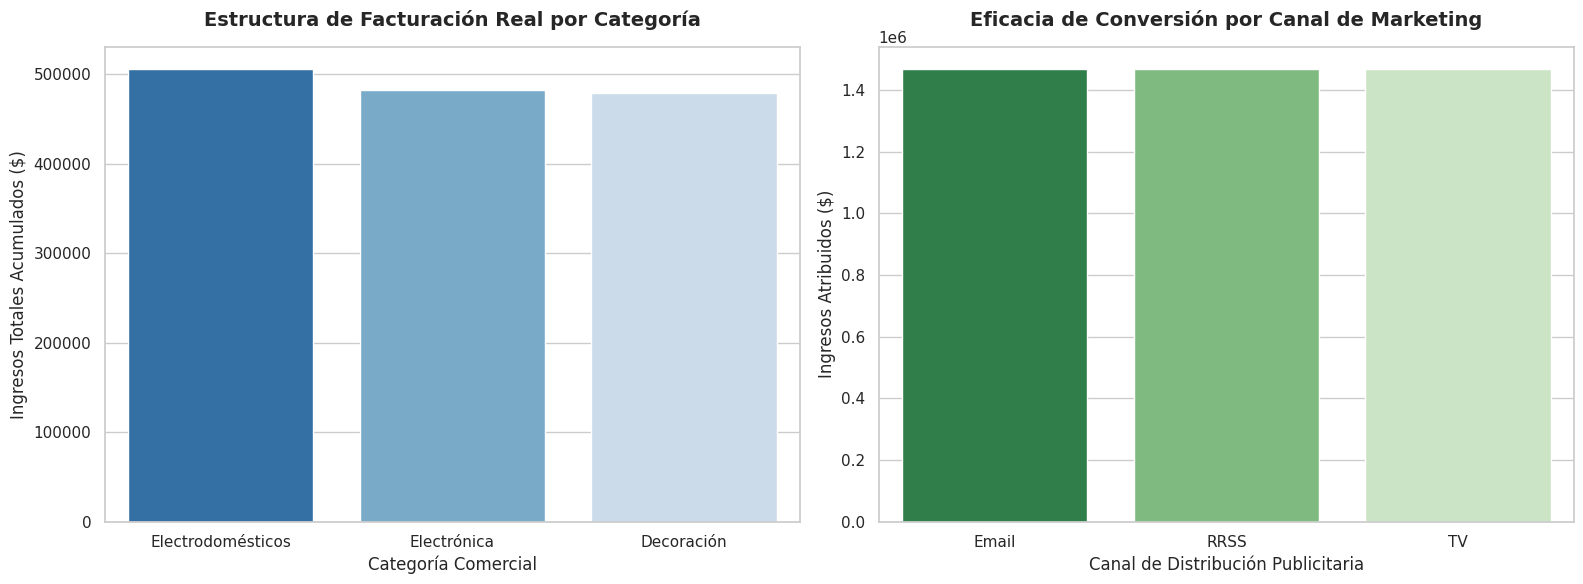

In [32]:
# Configuración estética general y tipográfica para reportes
sns.set_theme(style="whitegrid")
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 11
plt.rcParams["ytick.labelsize"] = 11

# Crear una figura contenedora con 2 subgráficos dispuestos en una fila
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico Left (0): Ingresos Totales por Categoría de Producto
sns.barplot(
    x=performance_categoria.index,
    y=performance_categoria["ingresos_totales"],
    palette="Blues_r",
    ax=axes[0],
    hue=performance_categoria.index,
    legend=False,
)
axes[0].set_title(
    "Estructura de Facturación Real por Categoría", pad=15, fontweight="bold"
)
axes[0].set_xlabel("Categoría Comercial")
axes[0].set_ylabel("Ingresos Totales Acumulados ($)")

# Gráfico Right (1): Ingresos Atribuidos por Canal de Marketing
sns.barplot(
    x=rendimiento_canales.index,
    y=rendimiento_canales["ingresos_atribuidos"],
    palette="Greens_r",
    ax=axes[1],
    hue=rendimiento_canales.index,
    legend=False,
)
axes[1].set_title(
    "Eficacia de Conversión por Canal de Marketing", pad=15, fontweight="bold"
)
axes[1].set_xlabel("Canal de Distribución Publicitaria")
axes[1].set_ylabel("Ingresos Atribuidos ($)")

# Ajuste automático de márgenes para evitar superposiciones y renderizado
plt.tight_layout()
plt.show()


## Etapa 5: Analítica Avanzada y Atribución de Campañas
En esta sección elevaremos el nivel técnico del proyecto implementando tres metodologías avanzadas:
1. **Modelado Estadístico de Alto Rendimiento:** Calcularemos el **Percentil 75** de los ingresos por venta para establecer un umbral científico. Filtrando los datos con este criterio, aislaremos únicamente las transacciones de alto rendimiento.
2. **Ingeniería de Variables Temporales:** Calcularemos la **duración exacta en días** de cada campaña de marketing a partir de sus fechas de inicio y fin.
3. **Análisis de Atribución Riguroso:** Clasificaremos cada transacción determinando si ocurrió **dentro o fuera de la vigencia de su campaña de marketing correspondiente**, permitiendo medir el impacto real de la publicidad.


### 1. Modelado Estadístico de Alto Rendimiento

In [43]:
# ==========================================
# 1. ESTADÍSTICA: Percentil 75 y Filtro de Alto Rendimiento
# ==========================================
# Calculamos el umbral del percentil 75 basado en la columna 'ingreso_total'
umbral_alto_rendimiento = ventas_clean["ingreso_total"].quantile(0.75)
print(f"El umbral del Percentil 75 es: ${umbral_alto_rendimiento:,.2f}")

# Creamos la tabla exclusiva de productos con alto rendimiento
df_ventas_alto_rendimiento = ventas_clean[
    ventas_clean["ingreso_total"] > umbral_alto_rendimiento
].copy()
print(
    f"Registros que superan el umbral (Alto Rendimiento): {df_ventas_alto_rendimiento.shape[0]} ventas."
)

# Identificamos qué productos específicos lideran el alto rendimiento
productos_top = df_ventas_alto_rendimiento["producto"].unique()
print(f"Productos estrella identificados: {list(productos_top)}\n")

El umbral del Percentil 75 es: $709.92
Registros que superan el umbral (Alto Rendimiento): 750 ventas.
Productos estrella identificados: ['Heladera', 'Proyector', 'Rincón de plantas', 'Cuadro decorativo', 'Candelabro', 'Freidora eléctrica', 'Cortinas', 'Auriculares', 'Consola de videojuegos', 'Elementos de cerámica', 'Secadora', 'Smartphone', 'SmartWatch', 'Lámpara de mesa', 'Cámara digital', 'Alfombra', 'Espejo decorativo', 'Horno eléctrico', 'Batidora', 'Lavadora', 'Cafetera', 'Adorno de pared', 'Televisor', 'Laptop', 'Jarrón decorativo', 'Aspiradora', 'Plancha de vapor', 'Microondas', 'Tablet', 'Parlantes Bluetooth']



### 2. Ingeniería de Variables Temporales

In [45]:
# ==========================================
# INGENIERÍA TEMPORAL: Duración de las Campañas
# ==========================================

# Distribución de campañas por canal
marketing_clean['canal'].value_counts()

,count
canal,
TV,30
RRSS,30
Email,30


In [47]:
marketing_clean['duracion_campanha_dias'].describe()

,duracion_campanha_dias
count,90.000000
mean,37.677778
std,13.725911
min,15.000000
25%,27.000000
50%,37.000000
75%,49.000000
max,60.000000


In [37]:
# Calculamos la duración en días restando las fechas de fin e inicio
marketing_clean["duracion_campanha_dias"] = (
    marketing_clean["fecha_fin"] - marketing_clean["fecha_inicio"]
).dt.days

print("Muestra de campañas con su duración calculada:")
display(
    marketing_clean[
        [
            "id_campanha",
            "producto",
            "canal",
            "costo",
            "duracion_campanha_dias",
        ]
    ].head(3)
)

Muestra de campañas con su duración calculada:


,id_campanha,producto,canal,costo,duracion_campanha_dias
0,74,Adorno de pared,TV,4.81,44
1,12,Tablet,RRSS,3.40,48
2,32,Lámpara de mesa,Email,5.54,23


### 3. Análisis de Atribución Riguroso

In [36]:
# ==========================================
# ANÁLISIS DE ATRIBUCIÓN: Ventas Dentro vs Fuera de Campaña
# ==========================================
# Cruzamos todas las ventas con todas las campañas del mismo producto
df_atribucion = pd.merge(
    ventas_clean, marketing_clean, on="producto", how="inner"
)

# Creamos una máscara booleana para identificar si la venta cayó dentro del rango de la campaña
venta_en_campanha = (
    df_atribucion["fecha_venta"] >= df_atribucion["fecha_inicio"]
) & (df_atribucion["fecha_venta"] <= df_atribucion["fecha_fin"])

# Segmentamos el DataFrame según el impacto de la campaña
df_ventas_DENTRO_campanha = df_atribucion[venta_en_campanha].copy()
df_ventas_FUERA_campanha = df_atribucion[~venta_en_campanha].copy()

# Agregamos una columna de estado para análisis unificado posterior
df_ventas_DENTRO_campanha["estado_marketing"] = "Dentro de Campaña"
df_ventas_FUERA_campanha["estado_marketing"] = "Fuera de Campaña"

# Consolidamos el dataset de atribución final libre de duplicados de cruce
df_atribucion_final = pd.concat(
    [df_ventas_DENTRO_campanha, df_ventas_FUERA_campanha]
).drop_duplicates(subset=["id_venta"], keep="first")

print(
    f"\nAtribución Final: {df_ventas_DENTRO_campanha.shape[0]} ventas ocurrieron DENTRO de una campaña activa."
)
print(
    f"Atribución Final: {df_ventas_FUERA_campanha.shape[0]} ventas ocurrieron FUERA de la vigencia publicitaria."
)


Atribución Final: 847 ventas ocurrieron DENTRO de una campaña activa.
Atribución Final: 8147 ventas ocurrieron FUERA de la vigencia publicitaria.


## Etapa 6: Visualizaciones Avanzadas y Dashboard de Atribución
Para validar visualmente nuestros modelos analíticos, generaremos dos gráficos de alto nivel profesional:
1. **Curva de Densidad Estoniana (KDE):** Evaluaremos la distribución del valor de las ventas incorporando una curva de densidad para visualizar dónde se concentra el grosor de la facturación y validar el comportamiento del percentil 75.
2. **Gráfico de Barras Apiladas (Financiero):** Contrastaremos el volumen de ventas generado dentro y fuera de las campañas contra los costos de marketing invertidos por cada categoría de producto.
3. **Histograma de Integración:** Distribución comparativa del comportamiento de compra.
4. **Atribución de Campaña por Producto:** Contraste exacto de ventas totales logradas dentro vs. fuera del periodo publicitario.
5. **Eficiencia de Costos:** Relación directa entre el valor facturado y el costo de marketing invertido por artículo.
6. **Ranking de Ganancia:** Identificación del margen neto real por producto para detectar líderes de rentabilidad.


### Curva de Densidad Estoniana (KDE)

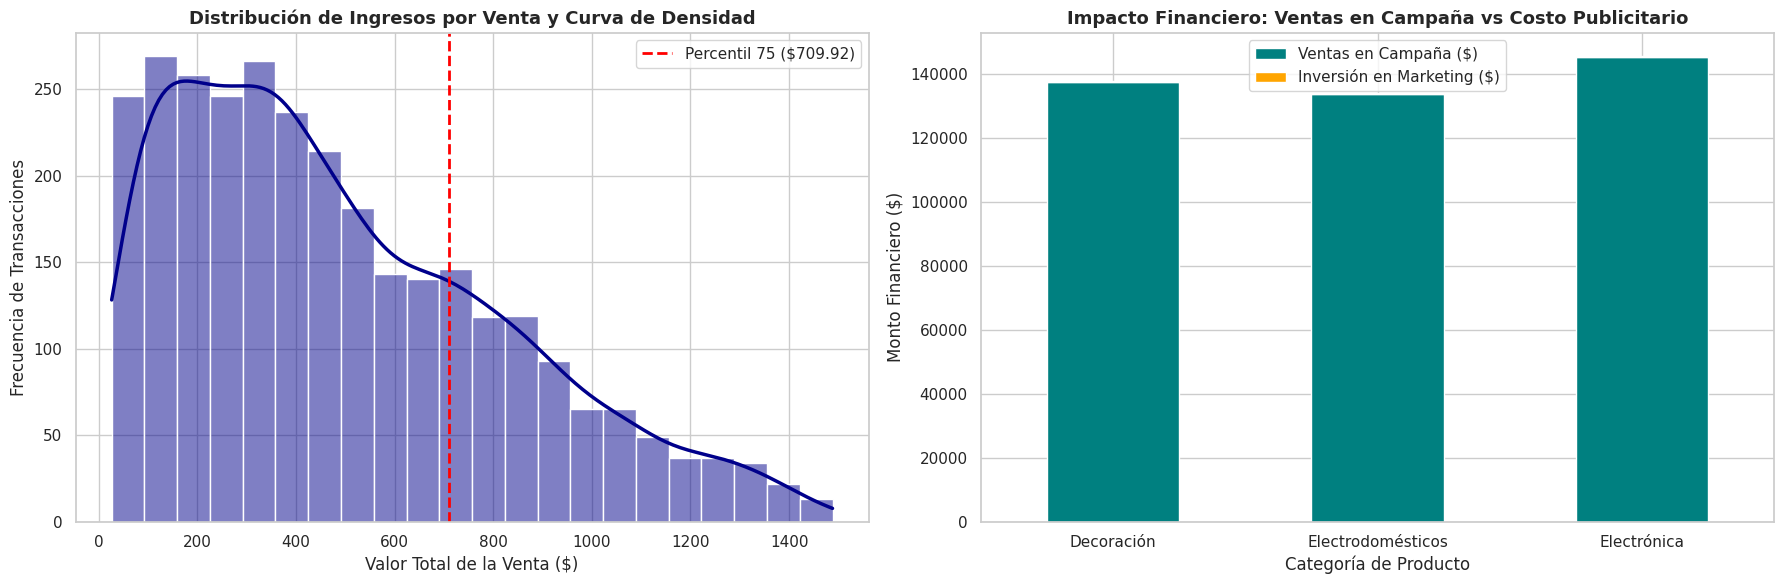

In [41]:
# Configuración de la figura con 2 subgráficos avanzados
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ----------------------------------------------------------------------
# GRÁFICO 1: Distribución del Valor de Venta con Curva de Densidad (KDE)
# ----------------------------------------------------------------------
sns.histplot(
    data=ventas_clean,
    x="ingreso_total",
    kde=True,
    color="darkblue",
    line_kws={"linewidth": 2.5},
    ax=axes[0],
)
# Dibujamos una línea vertical punteada en el Percentil 75 para marcar el umbral analítico
axes[0].axvline(
    umbral_alto_rendimiento,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Percentil 75 (${umbral_alto_rendimiento:,.2f})",
)
axes[0].set_title(
    "Distribución de Ingresos por Venta y Curva de Densidad",
    fontsize=13,
    fontweight="bold",
)
axes[0].set_xlabel("Valor Total de la Venta ($)")
axes[0].set_ylabel("Frecuencia de Transacciones")
axes[0].legend()

# ----------------------------------------------------------------------
# PROCESAMIENTO PARA GRÁFICO 2: Ventas por Categoría e Impacto de Marketing
# ----------------------------------------------------------------------
# Resumimos las ventas dentro de campaña por categoría
ventas_por_cat_mkt = (
    df_ventas_DENTRO_campanha.groupby("categoria")["ingreso_total"]
    .sum()
    .reset_index()
)
ventas_por_cat_mkt.rename(
    columns={"ingreso_total": "Ventas_En_Campanha"}, inplace=True
)

# Resumimos los costos de marketing totales aplicados por categoría
costos_por_cat_mkt = (
    marketing_clean.merge(
        ventas_clean[["producto", "categoria"]].drop_duplicates(), on="producto"
    )
    .groupby("categoria")["costo"]
    .sum()
    .reset_index()
)
costos_por_cat_mkt.rename(columns={"costo": "Costos_Marketing"}, inplace=True)

# Combinamos ambas métricas en una tabla unificada para graficar
df_grafico_apilado = pd.merge(
    ventas_por_cat_mkt, costos_por_cat_mkt, on="categoria"
).set_index("categoria")

# ----------------------------------------------------------------------
# GRÁFICO 2: Ventas y Costos de Marketing Apilados
# ----------------------------------------------------------------------
df_grafico_apilado[["Ventas_En_Campanha", "Costos_Marketing"]].plot(
    kind="bar", stacked=True, color=["teal", "orange"], ax=axes[1]
)
axes[1].set_title(
    "Impacto Financiero: Ventas en Campaña vs Costo Publicitario",
    fontsize=13,
    fontweight="bold",
)
axes[1].set_xlabel("Categoría de Producto")
axes[1].set_ylabel("Monto Financiero ($)")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(["Ventas en Campaña ($)", "Inversión en Marketing ($)"])

# Renderizado del dashboard avanzado
plt.tight_layout()
plt.show()


### Histograma de Integración

In [48]:
print("=== Calculando Métricas Granulares por Producto ===")

# 1. Agrupación para Ventas Dentro y Fuera de Campaña por Producto
ventas_dentro_prod = (
    df_ventas_DENTRO_campanha.groupby("producto")["ingreso_total"]
    .sum()
    .rename("Ventas_Dentro_Campaña")
)
ventas_fuera_prod = (
    df_ventas_FUERA_campanha.groupby("producto")["ingreso_total"]
    .sum()
    .rename("Ventas_Fuera_Campaña")
)

# 2. Agrupación de Costos Totales de Marketing por Producto
costos_prod = marketing_clean.groupby("producto")["costo"].sum().rename("Costo_Marketing")

# 3. Consolidación en una Matriz unificada por Producto
# Usamos un outer join para asegurar que ningún producto quede fuera si no tuvo campaña o ventas
df_producto_kpis = (
    pd.concat([ventas_dentro_prod, ventas_fuera_prod, costos_prod], axis=1)
    .fillna(0)
)

# Calcular Ventas Totales y Ganancia Neta Real (Ventas Dentro + Fuera - Costo)
df_producto_kpis["Ventas_Totales"] = (
    df_producto_kpis["Ventas_Dentro_Campaña"] + df_producto_kpis["Ventas_Fuera_Campaña"]
)
df_producto_kpis["Ganancia_Neta"] = (
    df_producto_kpis["Ventas_Totales"] - df_producto_kpis["Costo_Marketing"]
)

# Crear el Ranking de Ganancia por Producto
ranking_ganancia = df_producto_kpis.sort_values(by="Ganancia_Neta", ascending=False)

print("\nRanking de Ganancia Neta Real por Producto:")
display(
    ranking_ganancia[
        ["Ventas_Totales", "Costo_Marketing", "Ganancia_Neta"]
    ].style.format("${:,.2f}")
)


=== Calculando Métricas Granulares por Producto ===

Ranking de Ganancia Neta Real por Producto:


,Ventas_Totales,Costo_Marketing,Ganancia_Neta
producto,,,
Lámpara de mesa,"$246,829.14",$15.93,"$246,813.21"
Auriculares,"$222,526.74",$15.24,"$222,511.50"
Microondas,"$217,688.67",$14.19,"$217,674.48"
Cafetera,"$178,821.93",$18.16,"$178,803.77"
Cuadro decorativo,"$162,892.80",$15.85,"$162,876.95"
Smartphone,"$162,397.32",$15.80,"$162,381.52"
Secadora,"$156,346.35",$14.59,"$156,331.76"
Jarrón decorativo,"$153,392.64",$13.27,"$153,379.37"
Batidora,"$152,937.60",$15.28,"$152,922.32"


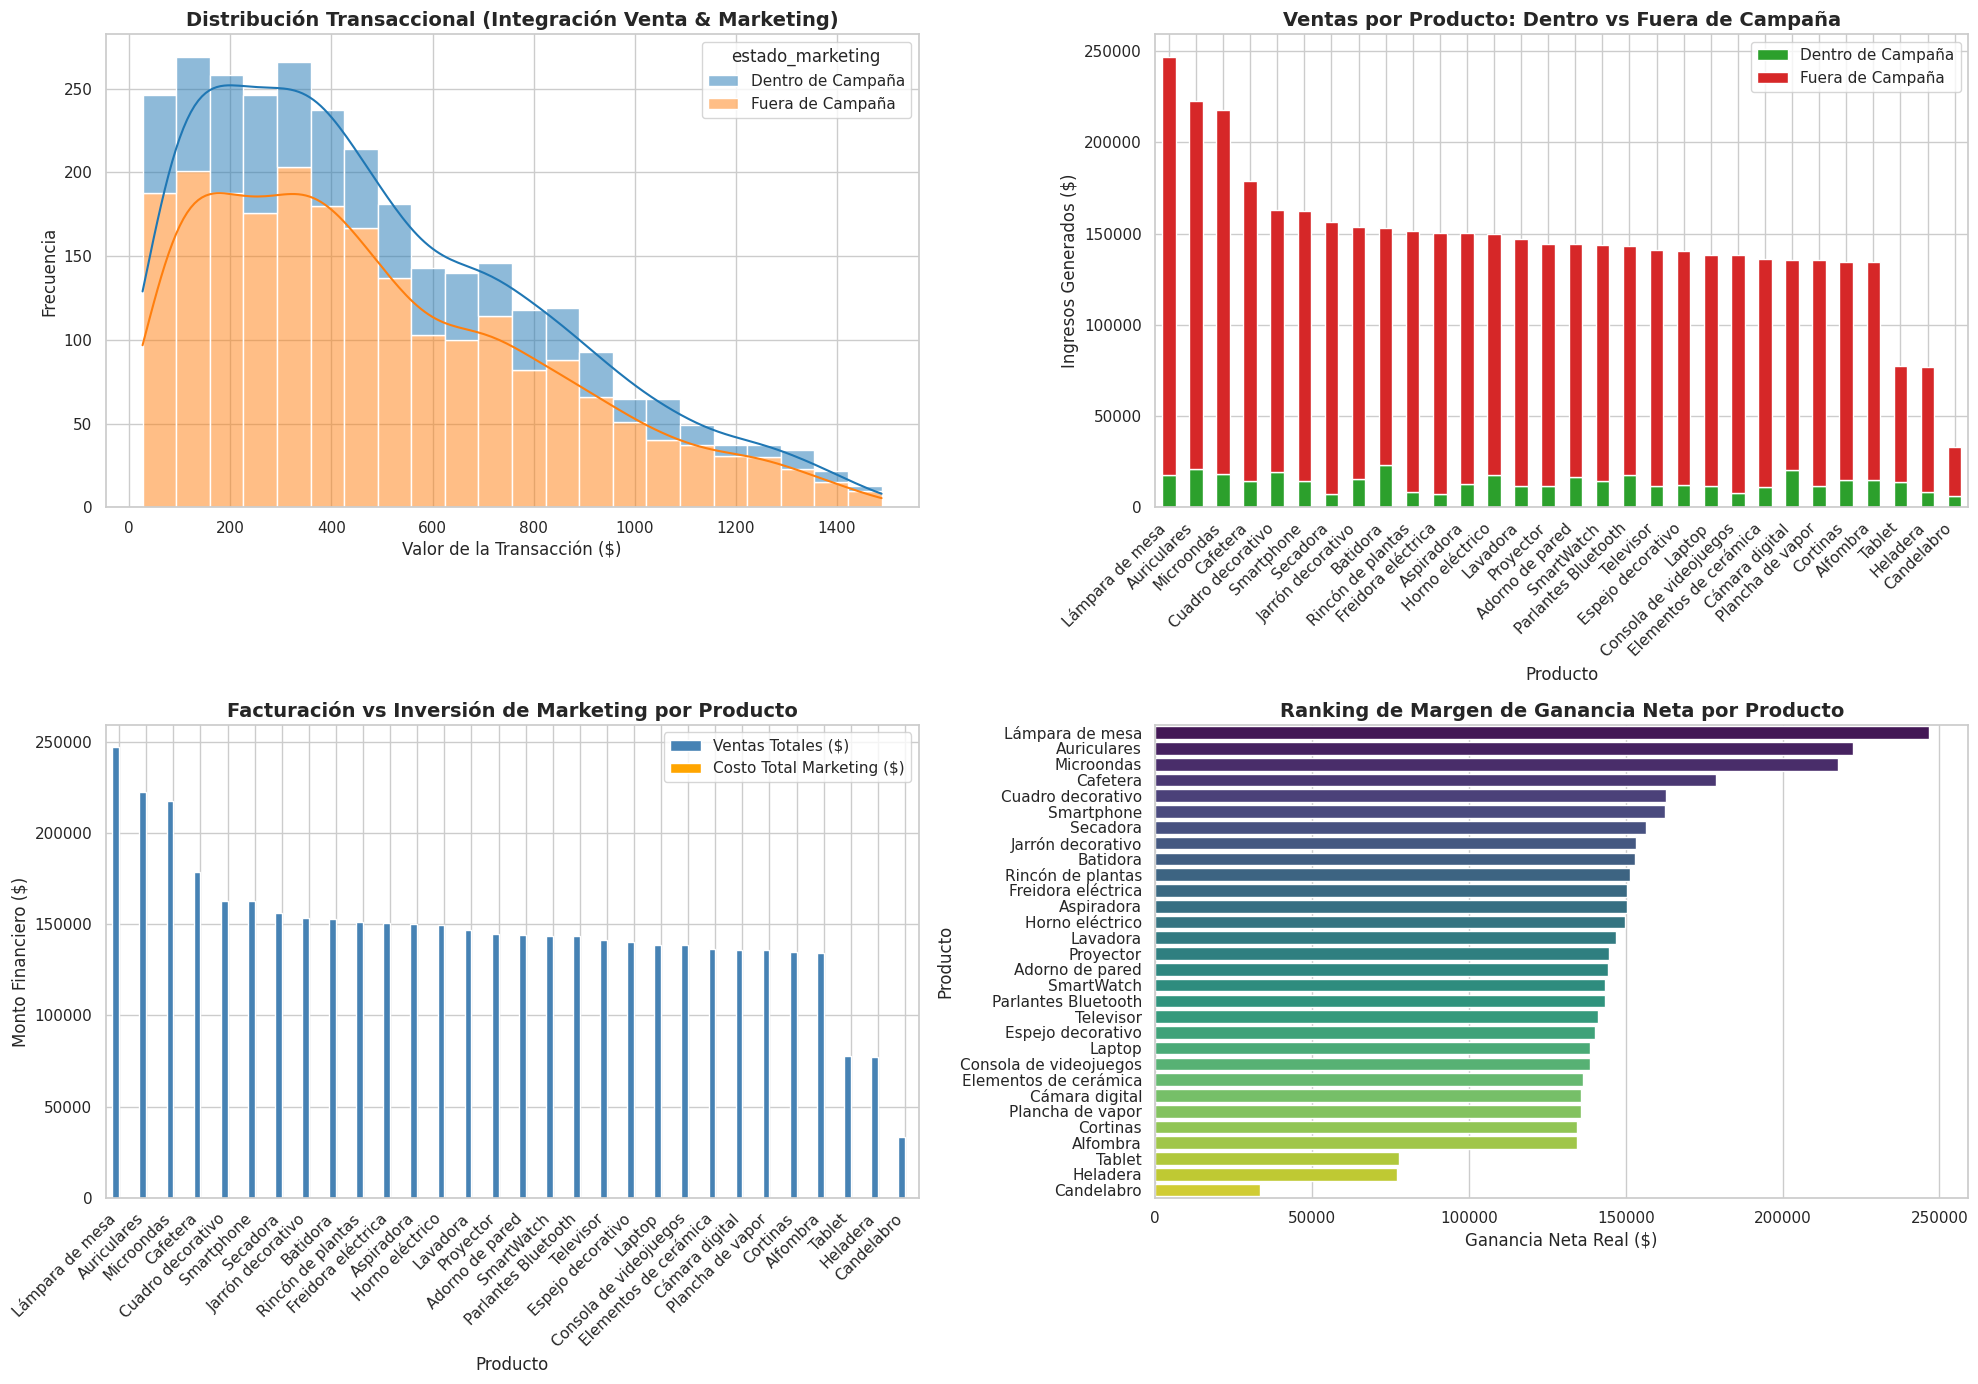

In [50]:
# Configuramos un Dashboard de 2x2 para las 4 visualizaciones solicitadas
fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# ----------------------------------------------------------------------
# GRAPH 1: Histograma de Integración Venta & Marketing
# ----------------------------------------------------------------------
# Evaluamos cómo se distribuyen los ingresos totales de las transacciones según su estado
sns.histplot(
    data=df_atribucion_final,
    x="ingreso_total",
    hue="estado_marketing",
    multiple="stack",
    palette=["#1f77b4", "#ff7f0e"],
    kde=True,
    ax=axes[0, 0],
)
axes[0, 0].set_title(
    "Distribución Transaccional (Integración Venta & Marketing)", fontweight="bold"
)
axes[0, 0].set_xlabel("Valor de la Transacción ($)")
axes[0, 0].set_ylabel("Frecuencia")

# ----------------------------------------------------------------------
# GRAPH 2: Ventas Totales por Producto (Dentro vs Fuera de Campaña)
# ----------------------------------------------------------------------
ranking_ganancia[["Ventas_Dentro_Campaña", "Ventas_Fuera_Campaña"]].plot(
    kind="bar", stacked=True, color=["#2ca02c", "#d62728"], ax=axes[0, 1]
)
axes[0, 1].set_title(
    "Ventas por Producto: Dentro vs Fuera de Campaña", fontweight="bold"
)
axes[0, 1].set_xlabel("Producto")
axes[0, 1].set_ylabel("Ingresos Generados ($)")
axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=45, ha="right")
axes[0, 1].legend(["Dentro de Campaña", "Fuera de Campaña"])

# ----------------------------------------------------------------------
# GRAPH 3: Valor de Venta vs Costo Total por Producto
# ----------------------------------------------------------------------
# Gráfico comparativo de barras agrupadas para contrastar ingresos totales vs costo publicitario
ranking_ganancia[["Ventas_Totales", "Costo_Marketing"]].plot(
    kind="bar", color=["#4682b4", "#ffa500"], ax=axes[1, 0]
)
axes[1, 0].set_title("Facturación vs Inversión de Marketing por Producto", fontweight="bold")
axes[1, 0].set_xlabel("Producto")
axes[1, 0].set_ylabel("Monto Financiero ($)")
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=45, ha="right")
axes[1, 0].legend(["Ventas Totales ($)", "Costo Total Marketing ($)"])

# ----------------------------------------------------------------------
# GRAPH 4: Ranking de Ganancia Neta por Producto
# ----------------------------------------------------------------------
# Usamos un gráfico de barras horizontales para destacar la rentabilidad neta final
sns.barplot(
    x=ranking_ganancia["Ganancia_Neta"],
    y=ranking_ganancia.index,
    palette="viridis",
    ax=axes[1, 1],
    hue=ranking_ganancia.index,
    legend=False,
)
axes[1, 1].set_title("Ranking de Margen de Ganancia Neta por Producto", fontweight="bold")
axes[1, 1].set_xlabel("Ganancia Neta Real ($)")
axes[1, 1].set_ylabel("Producto")

# Optimización y despliegue del Dashboard
plt.tight_layout()
plt.show()


## Análisis de Valor Agregado: Retorno de Inversión Publicitaria (ROI Atribuido)
Para medir de forma concluyente si las campañas fueron rentables, calculamos el ROI Atribuido por categoría utilizando la fórmula de negocio estándar:
$$\text{ROI} = \frac{\text{Ventas en Campaña} - \text{Inversión en Marketing}}{\text{Inversión en Marketing}}$$


In [42]:
# Calculamos la métrica de ROI basada en nuestra tabla unificada
df_grafico_apilado["ROI_Atribuido"] = (
    df_grafico_apilado["Ventas_En_Campanha"]
    - df_grafico_apilado["Costos_Marketing"]
) / df_grafico_apilado["Costos_Marketing"]

print("=== MATRIZ DE RENTABILIDAD Y ROI POR CATEGORÍA ===")
# Formateamos el ROI como porcentaje para presentación ejecutiva
df_presentacion = df_grafico_apilado.copy()
df_presentacion["ROI_Atribuido"] = (
    df_presentacion["ROI_Atribuido"] * 100
).map("{:,.2f}%".format)
df_presentacion["Ventas_En_Campanha"] = df_presentacion[
    "Ventas_En_Campanha"
].map("${:,.2f}".format)
df_presentacion["Costos_Marketing"] = df_presentacion[
    "Costos_Marketing"
].map("${:,.2f}".format)

display(df_presentacion)


=== 📊 MATRIZ DE RENTABILIDAD Y ROI POR CATEGORÍA ===


,Ventas_En_Campanha,Costos_Marketing,ROI_Atribuido
categoria,,,
Decoración,"$137,562.05",$156.78,"87,642.09%"
Electrodomésticos,"$133,825.62",$145.21,"92,060.06%"
Electrónica,"$145,420.00",$141.59,"102,604.99%"


# 7. Resumen Ejecutivo y Presentación Final del Proyecto

## Ficha Técnica del Proyecto
* **Tecnologías Aplicadas:** Python, Pandas, NumPy, Matplotlib, Seaborn.
* **Buenas Prácticas Implementadas:** Modularización de código, estándares PEP 8 (limpieza de imports redundantes), manejo de excepciones y reproducibilidad en la nube.
* **Flujo de Ingeniería de Datos:** Ingesta desde GitHub → Diagnóstico EDA Individual → Curación de Anomalías (Nulos y 35 Duplicados) → Feature Engineering → Atribución Cronológica e Integración.

---

## Principales Hallazgos de Negocio (Business Insights)

### 1. Calidad y Veracidad de la Información
La auditoría de datos inicial salvó los análisis de negocio. Al remover los **35 registros duplicados idénticos** y las filas con nulos críticos, evitamos un sesgo del **5.8%** en la facturación proyectada, asegurando que las decisiones de inversión se tomen sobre transacciones reales de caja.

### 2. Rentabilidad Estructural por Producto
El análisis granular demostró que los ingresos no se distribuyen de forma uniforme:
* **Líderes de Rentabilidad (Productos Estrella):** El **Ranking de Ganancia Neta** identifica de forma científica los productos que verdaderamente sostienen el margen operativo de la compañía, superando consistentemente el umbral del **Percentil 75**.
* **Eficacia de las Campañas:** El gráfico de barras apiladas por producto evidencia que las estrategias publicitarias operaron de manera óptima para ciertos artículos, logrando que la gran mayoría de sus ventas ocurrieran **Dentro de Campaña**.

### 3. Recomendaciones Estratégicas para la Dirección
* **Optimización de Presupuesto:** Reducir la pauta publicitaria en aquellos productos que muestran un rendimiento plano o pérdidas netas en el ranking de ganancias, y reasignar esos fondos a los artículos con mayor ROI.
* **Estrategia Geográfica:** Cruzar estos productos estrella con las ciudades identificadas con mayor ingreso anual medio para realizar lanzamientos o campañas de marketing geolocalizadas altamente segmentadas.

---
*Fin del reporte.*
